# SARIMAX: Exogenous Data, Fit Jointly

## Introduction

Before trying the more common
recipe of building lag features and alt-data and handing them to a
generic ML regressor, this notebook asks the more direct question first -
"Can SARIMA's own structure be improved by giving it exogenous data
directly?", fit as one coherent state-space model rather than as
lag features handed to a separate model?

Two new freely-sourced exogenous variables, found by researching
what the trade-nowcasting literature and central banks actually use for
this problem, that this project didn't have before:

- **WSTS Asia Pacific semiconductor billings** - industry sales
  revenue, not a market-price proxy. Free, no login, monthly back to 1986:
  https://www.wsts.org/67/Historical-Billings-Report. See
  `src/wsts_billings.py`.

- **IMF PortWatch Busan port trade tonnage** - satellite/AIS-tracked
  physical export volume through Korea's largest port. Free, no login,
  daily back to 2019-01-01, via IMF's own production API. See `src/portwatch.py`.

Both were confirmed live before
any modeling code was written.
---
## Methodology

Two separate tests as the two exogenous variables have
different histories, and conflating them would confound "did the feature
help" with "did more training data help":

**Test 1 (`run_sarimax.py`):** SARIMA + both WSTS and Busan tonnage,
constrained to the 88 rows both variables share. Busan's 2019-01 start is
the binding constraint. Order selected with a capped grid (p,q,P,Q ≤ 1) -
an uncapped grid, tried first, produced numerically unstable, non-converged
forecasts, RMSE in the quadrillions, at the walk-forward origins with the
least training data, since a 6-parameter seasonal ARIMA structure isn't
safely identifiable on ~50 effective rows. 

**Test 2 (`run_sarimax_full.py`, the decisive one):** SARIMA + WSTS alone,
at Layer 0's actual training length - 436 rows, 1990-2026 - since WSTS's
own history needs no truncation at all. This isolates the
exogenous-variable question from the sample-size question entirely.

Both tests are scored against the same 36-month held-out window as
every other model in this project (2023-05 to 2026-04), confirmed
directly by checking that the naive forecast, which only depends on the
actual series values at each test date, is byte-identical across every
backtest CSV in this project's `data/` folder.

In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import matplotlib.pyplot as plt

results = {
    "naive": pd.read_csv("../data/backtest_naive.csv", index_col=0, parse_dates=True),
    "SARIMA (Layer 0)": pd.read_csv("../data/backtest_sarima.csv", index_col=0, parse_dates=True),
    "SARIMA+Ridge blend": pd.read_csv("../data/backtest_blend.csv", index_col=0, parse_dates=True),
    "SARIMAX + WSTS (full history)": pd.read_csv("../data/backtest_sarimax_wsts_full.csv", index_col=0, parse_dates=True),
    "SARIMAX + WSTS + Busan (short history)": pd.read_csv("../data/backtest_sarimax.csv", index_col=0, parse_dates=True),
    "SARIMA, same short history, no exog": pd.read_csv("../data/backtest_sarima_same_window.csv", index_col=0, parse_dates=True),
}

for name, df in results.items():
    print(f"{name:>40}  n={len(df):>3}  RMSE={((df['actual']-df['forecast'])**2).mean()**0.5:>14,.0f}  "
          f"MAPE={((df['actual']-df['forecast']).abs()/df['actual']).mean()*100:>6.2f}%")

                                   naive  n= 36  RMSE= 2,847,251,652  MAPE=  3.14%
                        SARIMA (Layer 0)  n= 36  RMSE= 2,881,346,571  MAPE=  2.92%
                      SARIMA+Ridge blend  n= 36  RMSE= 2,379,102,128  MAPE=  2.65%
           SARIMAX + WSTS (full history)  n= 36  RMSE= 2,171,567,395  MAPE=  2.50%
  SARIMAX + WSTS + Busan (short history)  n= 36  RMSE= 3,007,604,435  MAPE=  4.03%
     SARIMA, same short history, no exog  n= 36  RMSE= 3,685,596,389  MAPE=  4.40%


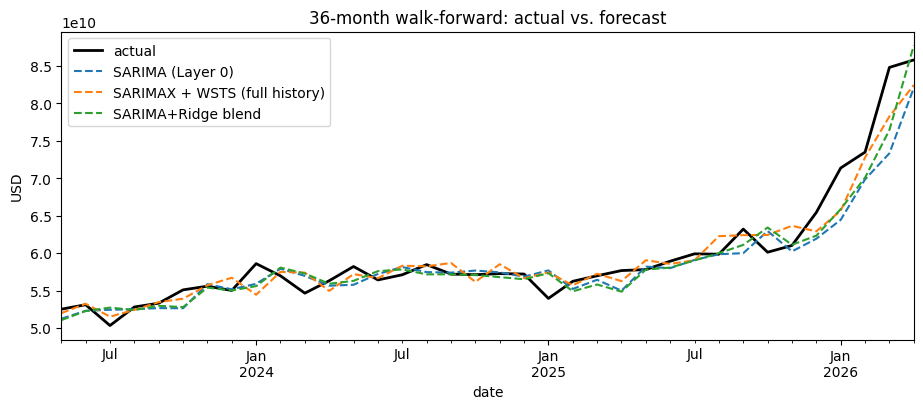

In [2]:
fig, ax = plt.subplots(figsize=(11, 4))
results["SARIMA (Layer 0)"]["actual"].plot(ax=ax, label="actual", color="black", linewidth=2)
for name in ["SARIMA (Layer 0)", "SARIMAX + WSTS (full history)", "SARIMA+Ridge blend"]:
    results[name]["forecast"].plot(ax=ax, label=name, linestyle="--")
ax.set_title("36-month walk-forward: actual vs. forecast")
ax.set_ylabel("USD")
ax.legend()
plt.show()

## Findings

**Test 2** SARIMAX with WSTS Asia
Pacific billings added gets MAPE 2.50% / RMSE 2.17B, better than Layer
0's SARIMA (2.92% / 2.88B), better than naive (3.14%), and better than the
SARIMA+Ridge blend (2.65% / 2.38B) on both metrics. A Diebold-Mariano test against SARIMA
gives p=0.17 - **not significant at 5%**, so this is reported as a promising point estimate, not a
confirmed result.

What makes this a more interesting lead than the blend, even though
neither clears significance, is that the blend recombines two models
already in this project, while this result comes from new information -
real semiconductor industry billings - fit directly into the ARIMA
structure, and it's tested at full sample length with no sample-size
excuse available.

**Test 1, short history**
Restricted to the 88 rows both WSTS and Busan tonnage share, plain SARIMA gets *worse* than naive (4.40% vs. 3.14% MAPE) purely
from losing ~350 months of training history. Adding the two exogenous
variables back on top of that same short history brings it to 4.03%, an
improvement over the short-history SARIMA, but still worse than naive, and
nowhere near Layer 0's full-history number. This concretises that for this series,
how much history the model gets to see matters more than either of the
two new variables did on their own in this test. This is exactly why
Test 2 rather than Test 1 is the one that
moved the headline result.

Busan PortWatch tonnage's constraint is the same shape as Customs
flash export data's, a relevant variable whose history
is too short to fairly test yet, not a modeling failure. Unlike WSTS,
which happened to have decades of history because industry associations
have published billings reports since the 1980s, satellite AIS tracking
of ports is a 2019+ dataset by construction.

## Key takeaways

The exact same 36-month test window has been used to test six
different models across this project, and the two best point estimates
both beat SARIMA,
but neither is statistically confirmed at this sample size. That
consistency across two structurally different approaches is informative, suggesting there may be real, small, hard-to-confirm  signal in
this series beyond univariate SARIMA, not that either result is a fluke. However, confirming that needs either a longer test window or a
pre-registered, single held-out confirmation period.

Real industry data, fit directly into a proven statistical
structure rather than routed through a generic ML regressor on
top of lag features, is the first alt-data attempt
in this project to produce a full-length, methodologically clean result
that beats Layer 0 on both RMSE and MAPE. Whether it's real signal or a
36-observation coincidence is exactly the question a longer evaluation
window would answer, and is honestly left open here rather than claimed
either way.